In [1]:
import numpy as np
from scipy.special import erf
import maps as mp
import scipy.optimize as opt
import matplotlib.pyplot as plt
import importlib

In [2]:
importlib.reload(mp)

<module 'maps' from '/Users/lucaraffo/Desktop/STOCH/maps.py'>

In [3]:
# observation times
t_obs = np.arange(1, 6)          # [1,2,3,4,5]

# observed noisy data
y_obs= np.array([0.18, 0.32, 0.42, 0.49, 0.54])

# noise variance sigma^2
sigma2 = 1e-3

In [4]:
def a_ox(x1):
    return 0.4 + 0.4 * (1.0 + erf(x1 / np.sqrt(2.0)))

def b_ox(x2):
    return 0.01 + 0.15 * (1.0 + erf(x2 / np.sqrt(2.0)))

def B_model(t, x):
    x1 = x[:, 0]
    x2 = x[:, 1]
    a = a_ox(x1)
    b = b_ox(x2)
    out = a[:, None] * (1.0 - np.exp(-b[:, None] * t[None, :]))
    if x.ndim == 1:
        return out[0]
    else:
        return out

def log_prior(x):
    lp = -0.5 * np.sum(x * x, axis = 1)
    if x.ndim == 1:
        return lp[0]
    else:
        return lp

def log_likelihood(x):
    pred = B_model(t_obs, x)
    if pred.ndim == 1:
        r = y_obs - pred
        return -0.5 * np.sum(r * r) / sigma2
    r = y_obs[None, :] - pred
    return -0.5 * np.sum(r * r, axis = 1) / sigma2

def log_posterior(x):
    return log_likelihood(x) + log_prior(x)


In [5]:
# create degree-d map
d = 3
T = mp.TriangularTransport2D(degree = d)

# initial parameters near identity
theta0 = T.initial_theta()

# fixed number of samples from prior
M = 2000
X = np.random.randn(M, 2)


def neg_log_KL(theta):
    """ monte carlo approximation of eq. (9), up to an additive constant """

    Z = T.forward(X, theta)                 # pushforward 
    log_pi = log_posterior(Z)              # log pi^y(z)
    log_det = T.log_det_jacobian(X, theta)

    return np.mean(-log_pi - log_det)


# run optimization
res = opt.minimize(neg_log_KL, theta0, method = "L-BFGS-B", options = {"maxiter": 200})

theta_star = res.x
print("optimization success:", res.success)
print("final objective:", res.fun)

optimization success: True
final objective: 4.6224504909185455


In [135]:
N_samples = 20000
X_prior = np.random.randn(N_samples, 2)      # samples from eta
Z_post = T.forward(X_prior, theta_star)      # transported samples

# posterior expectations
mean_post = Z_post.mean(axis = 0)
print("approximate posterior mean E[x1], E[x2]:", mean_post)

approximate posterior mean E[x1], E[x2]: [0.02822051 0.92263687]


In [146]:
def plot_colored_evolution(X_prior, Z_post, cmap = "viridis"):
    """ X_prior : (N,2) initial samples, Z_post  : (N,2) pushed-forward samples """

    N = X_prior.shape[0]
    colors = np.linalg.norm(Z_post - X_prior, axis = 1)

    fig, axes = plt.subplots(1, 2, figsize = (12, 6))

    # prior
    sc0 = axes[0].scatter(X_prior[:, 0], X_prior[:, 1], c = colors, cmap = cmap, s = 10, alpha = 0.6)
    # axes[0].set_title("initial samples (prior)", fontsize = 20)
    # axes[0].set_xlabel(r"$x_1$", fontsize = 18)
    # axes[0].set_ylabel(r"$x_2$", fontsize = 18)
    # axes[0].axis("equal")

    # pushforward
    axes[1].scatter(Z_post[:, 0], Z_post[:, 1], c = colors, cmap = cmap, s = 10, alpha = 0.6)
    # axes[1].set_title("evolved samples (pushforward)", fontsize = 20)
    # axes[1].set_xlabel(r"$z_1$", fontsize = 18)
    # axes[1].set_ylabel(r"$z_2$", fontsize = 18)
    # axes[1].axis("equal")

    axes[0].set_xlim(-4, 4)
    axes[0].set_ylim(-4, 4)

    axes[1].set_xlim(-0.8, 3.5)
    axes[1].set_ylim(-0.5, 4.0)
    
    plt.tight_layout()
    plt.show()

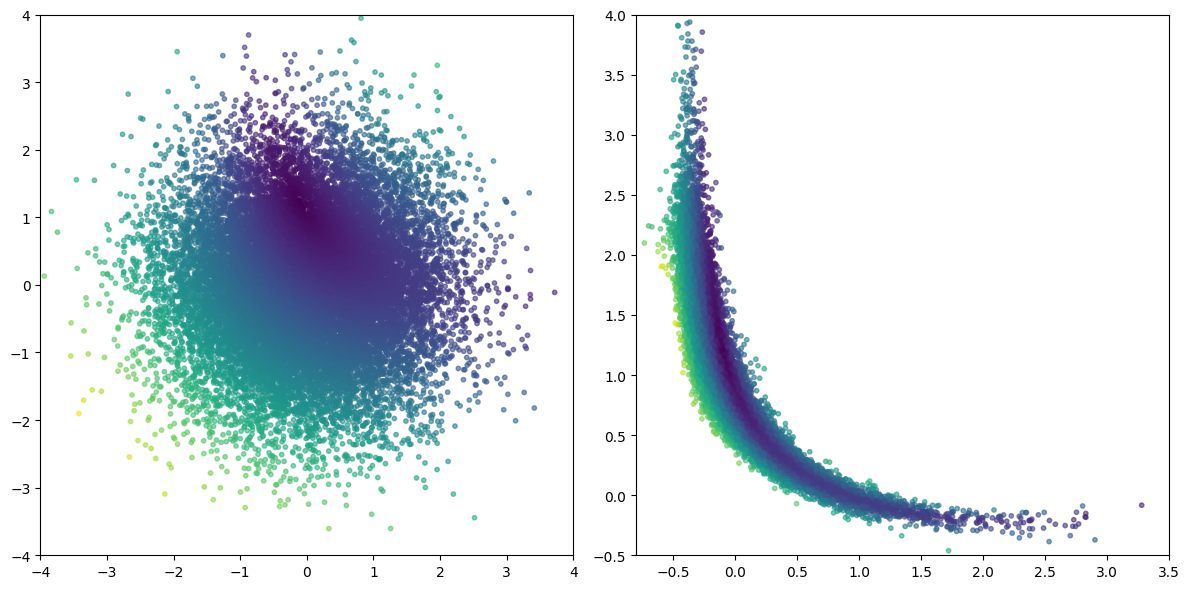

In [147]:
plot_colored_evolution(X_prior, Z_post)

In [9]:
T1 = mp.TriangularTransport2D(degree = 1)
thetaT1 = np.load("thetaT1.npy")

T2 = mp.TriangularTransport2D(degree = 2)
thetaT2 = np.load("thetaT2.npy")

T3 = mp.TriangularTransport2D(degree = 3)
thetaT3 = np.load("thetaT3.npy")

T4 = mp.TriangularTransport2D(degree = 4)
thetaT4 = np.load("thetaT4.npy")

In [10]:
def tmis(n_iter, T, theta, log_posterior, seed = 12):
    """ independence sampler with the transport map in the proposal """

    # random seed
    rng = np.random.default_rng(seed)

    # starting prior sample
    eta = np.zeros(2, dtype = float).reshape((1, 2))

    # pushed sample
    x = T.forward(eta, theta)

    chain = [x[0].copy()] * n_iter
    acc_count = 0

    for i in range(1, n_iter):

        # acceptance probability
        u = rng.uniform()

        # proposal
        etap = rng.standard_normal(size = (1, 2))
        xp = T.forward(etap, theta)

        log_fY = log_posterior(xp)[0]
        log_fX = log_posterior(x)[0]

        log_gY = log_prior(etap)[0] - T.log_det_jacobian(etap, theta)[0]
        log_gX = log_prior(eta)[0]  - T.log_det_jacobian(eta,  theta)[0]

        log_acc = (log_fY - log_fX) + (log_gX - log_gY)

        if log_acc >= 0:
            acc = 1.0
        
        else:
            acc = np.exp(log_acc)

        if u < acc:
            x = xp
            eta = etap
            acc_count += 1

        chain[i] = x[0].copy()

    return np.array(chain), acc_count / n_iter

In [11]:
n_iter = 25000

In [12]:
def acf_2d(x, max_lag = 2000):
	""" autocorrelation for different lags """

	x = np.asarray(x, dtype = float)
	n = x.shape[0]

	mean = x.mean(axis = 0)
	xc = x - mean

	# total variance (trace of covariance)
	var = np.mean(np.sum(xc * xc, axis = 1))

	out = np.zeros(max_lag + 1)
	out[0] = 1.0

	for k in range(1, max_lag + 1):
		num = np.mean(np.sum(xc[:-k] * xc[k:], axis = 1))
		out[k] = num / var

	return out

In [13]:
def ess_2d(x, max_lag = 2000):
	""" effective sample size function """

	r = acf_2d(x, max_lag = max_lag)
	s = 0.0
	for k in range(1, len(r)):
		if r[k] < 0:
			break
		s += r[k]
	return len(x) / (1.0 + 2.0 * s)

In [14]:
n_iter = 25000
samples1, acc1 = tmis(n_iter, T1, thetaT1, log_posterior)


# posterior means
mean_x = samples1.mean(axis = 0)

# global ess
ess_global = ess_2d(samples1, max_lag = 2000)

print("acceptance rate:", round(acc1, 3))
print("e[x|y] is approximately equal to", mean_x)
print("effective sample size is approximately", int(ess_global), "over", len(samples1))


acceptance rate: 0.769
e[x|y] is approximately equal to [0.00546617 0.94807818]
effective sample size is approximately 4538 over 25000


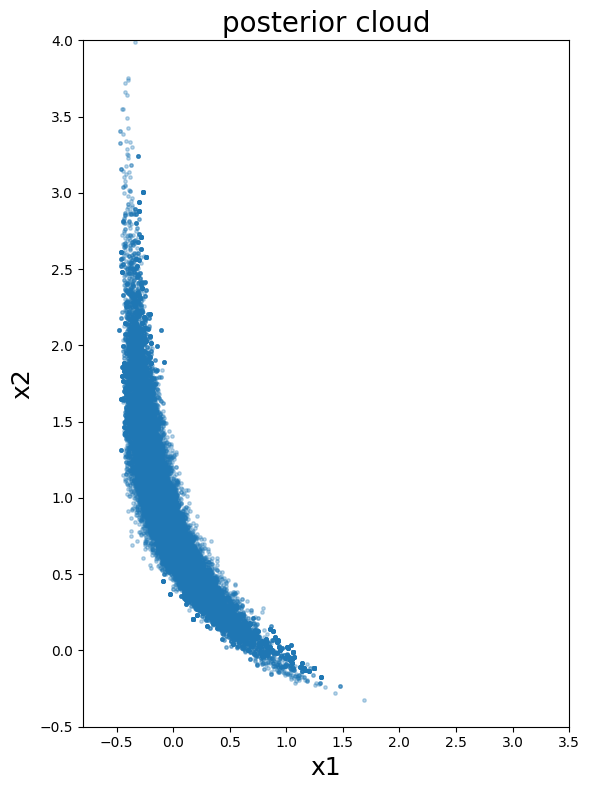

In [15]:
# posterior cloud
x1 = samples1[:, 0]
x2 = samples1[:, 1]
plt.figure(figsize=(6, 8))
plt.scatter(x1, x2, s = 6, alpha = 0.3)
plt.title("posterior cloud", fontsize = 20)
plt.xlabel("x1", fontsize = 18)
plt.ylabel("x2", fontsize = 18)
plt.ylim(-0.5, 4)
plt.xlim(-0.8, 3.5)
plt.tight_layout()
plt.show()

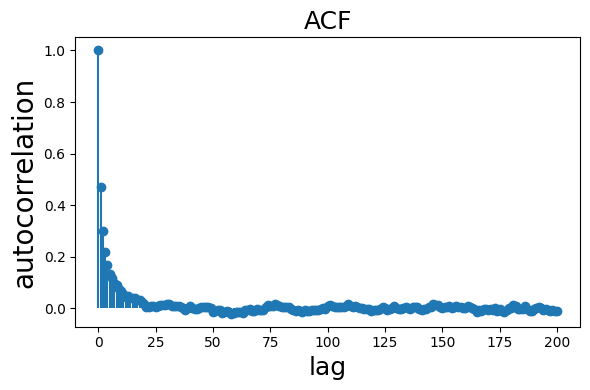

In [16]:
# acf 2D
max_lag = 200
acf = acf_2d(samples1, max_lag)

fig, ax = plt.subplots(figsize=(6, 4))
ax.stem(range(max_lag + 1), acf, basefmt=" ", markerfmt="o")
ax.set_title("ACF", fontsize = 18)
ax.set_xlabel("lag", fontsize = 18)
ax.set_ylabel("autocorrelation", fontsize = 20)

plt.tight_layout()
plt.show()

In [17]:
n_iter = 25000
samples2, acc2 = tmis(n_iter, T2, thetaT2, log_posterior)


# posterior means
mean_x = samples2.mean(axis = 0)

# global ess
ess_global = ess_2d(samples2, max_lag = 2000)

print("acceptance rate:", round(acc2, 3))
print("e[x|y] is approximately equal to", mean_x)
print("effective sample size is approximately", int(ess_global), "over", len(samples2))

acceptance rate: 0.882
e[x|y] is approximately equal to [0.02729211 0.94089339]
effective sample size is approximately 12071 over 25000


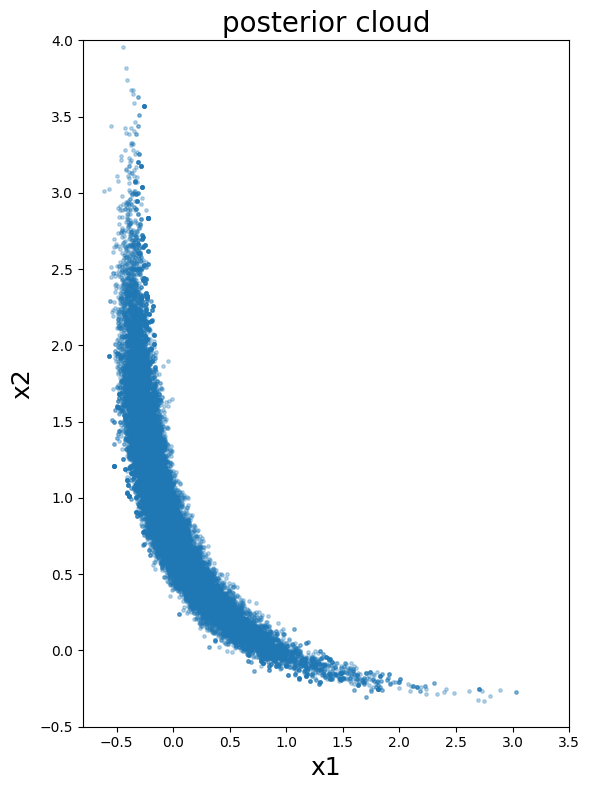

In [18]:
# posterior cloud
x1 = samples2[:, 0]
x2 = samples2[:, 1]
plt.figure(figsize=(6, 8))
plt.scatter(x1, x2, s = 6, alpha = 0.3)
plt.title("posterior cloud", fontsize = 20)
plt.xlabel("x1", fontsize = 18)
plt.ylabel("x2", fontsize = 18)
plt.ylim(-0.5, 4)
plt.xlim(-0.8, 3.5)
plt.tight_layout()
plt.show()

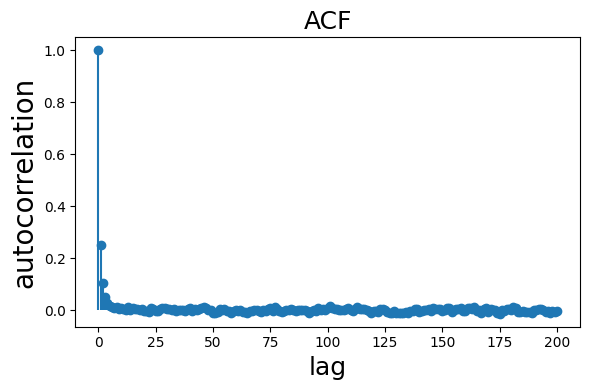

In [19]:
# acf 2D
max_lag = 200
acf = acf_2d(samples2, max_lag)

fig, ax = plt.subplots(figsize=(6, 4))
ax.stem(range(max_lag + 1), acf, basefmt=" ", markerfmt="o")
ax.set_title("ACF", fontsize = 18)
ax.set_xlabel("lag", fontsize = 18)
ax.set_ylabel("autocorrelation", fontsize = 20)

plt.tight_layout()
plt.show()

In [20]:
n_iter = 25000
samples3, acc3 = tmis(n_iter, T3, thetaT3, log_posterior)


# posterior means
mean_x = samples3.mean(axis = 0)

# global ess
ess_global = ess_2d(samples3, max_lag = 2000)

print("acceptance rate:", round(acc3, 3))
print("e[x|y] is approximately equal to", mean_x)
print("effective sample size is approximately", int(ess_global), "over", len(samples3))

acceptance rate: 0.922
e[x|y] is approximately equal to [0.03483735 0.93586488]
effective sample size is approximately 14712 over 25000


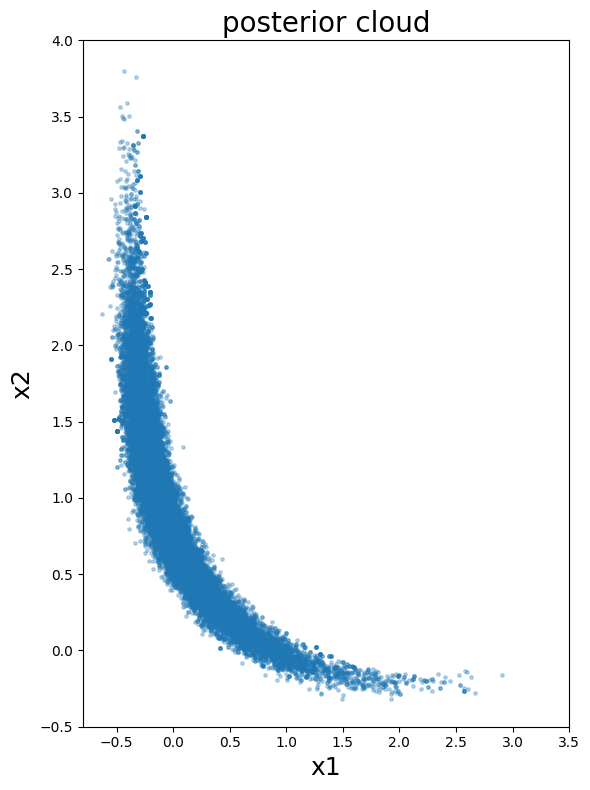

In [21]:
# posterior cloud
x1 = samples3[:, 0]
x2 = samples3[:, 1]
plt.figure(figsize=(6, 8))
plt.scatter(x1, x2, s = 6, alpha = 0.3)
plt.title("posterior cloud", fontsize = 20)
plt.xlabel("x1", fontsize = 18)
plt.ylabel("x2", fontsize = 18)
plt.ylim(-0.5, 4)
plt.xlim(-0.8, 3.5)
plt.tight_layout()
plt.show()

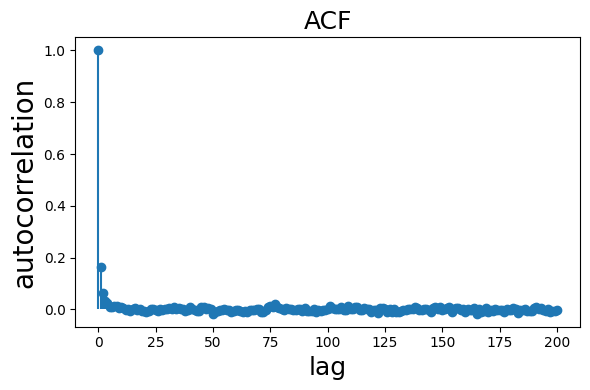

In [22]:
# acf 2D
max_lag = 200
acf = acf_2d(samples3, max_lag)

fig, ax = plt.subplots(figsize=(6, 4))
ax.stem(range(max_lag + 1), acf, basefmt=" ", markerfmt="o")
ax.set_title("ACF", fontsize = 18)
ax.set_xlabel("lag", fontsize = 18)
ax.set_ylabel("autocorrelation", fontsize = 20)

plt.tight_layout()
plt.show()

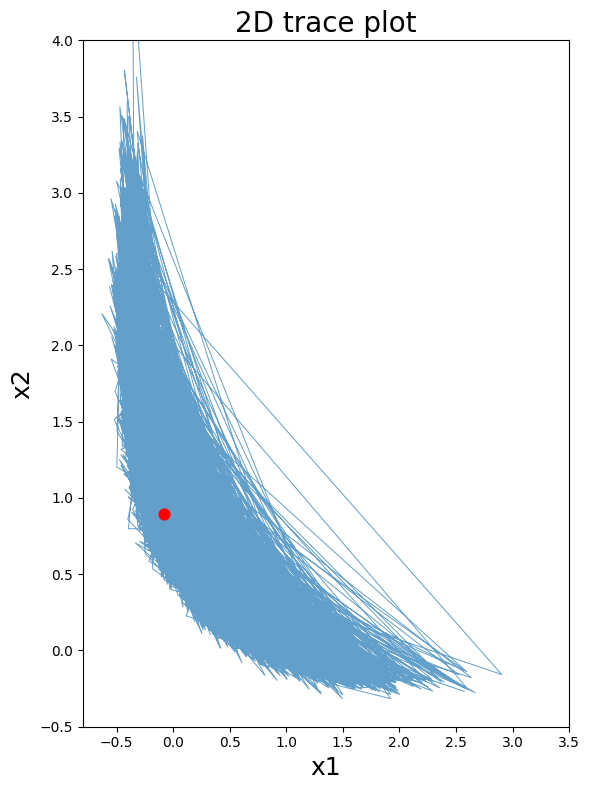

In [23]:
# 2d trace plot
plt.figure(figsize=(6, 8))

plt.plot(samples3[:, 0], samples3[:, 1], linewidth=0.7, alpha=0.7)

# starting point
plt.scatter(samples3[0, 0], samples3[0, 1], color="red", s=60, zorder=3)

plt.xlabel("x1", fontsize=18)
plt.ylabel("x2", fontsize=18)
plt.title("2D trace plot", fontsize=20)
plt.ylim(-0.5, 4)
plt.xlim(-0.8, 3.5)

plt.tight_layout()
plt.show()

In [24]:
n_iter = 25000
samples4, acc4 = tmis(n_iter, T4, thetaT4, log_posterior)


# posterior means
mean_x = samples4.mean(axis = 0)

# global ess
ess_global = ess_2d(samples4, max_lag = 2000)

print("acceptance rate:", round(acc4, 3))
print("e[x|y] is approximately equal to", mean_x)
print("effective sample size is approximately", int(ess_global), "over", len(samples4))

acceptance rate: 0.94
e[x|y] is approximately equal to [0.04098356 0.92889776]
effective sample size is approximately 19556 over 25000


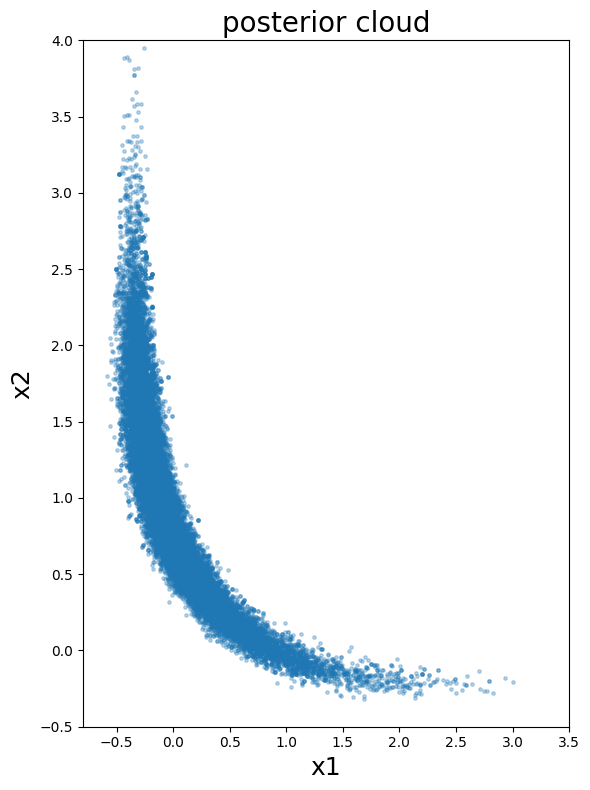

In [25]:
# posterior cloud
x1 = samples4[:, 0]
x2 = samples4[:, 1]
plt.figure(figsize=(6, 8))
plt.scatter(x1, x2, s = 6, alpha = 0.3)
plt.title("posterior cloud", fontsize = 20)
plt.xlabel("x1", fontsize = 18)
plt.ylabel("x2", fontsize = 18)
plt.ylim(-0.5, 4)
plt.xlim(-0.8, 3.5)
plt.tight_layout()
plt.show()

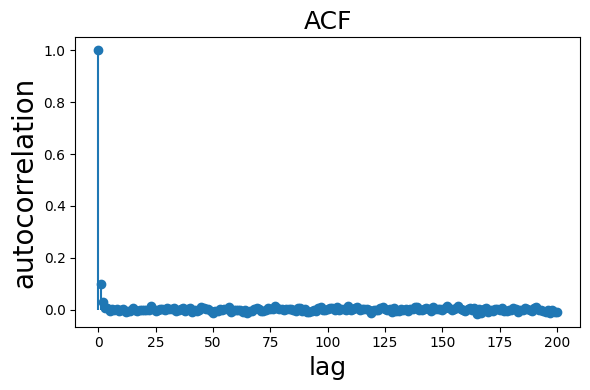

In [26]:
# acf 2D
max_lag = 200
acf = acf_2d(samples4, max_lag)

fig, ax = plt.subplots(figsize=(6, 4))
ax.stem(range(max_lag + 1), acf, basefmt=" ", markerfmt="o")
ax.set_title("ACF", fontsize = 18)
ax.set_xlabel("lag", fontsize = 18)
ax.set_ylabel("autocorrelation", fontsize = 20)

plt.tight_layout()
plt.show()

In [27]:
def tmis_rwm(n_iter, T, theta, log_posterior, gamma = 0.5, step = 0.18, seed = 12):
    """ select tmis with probability gamma and rwm with probability 1 - gamma """

    # random numbers generator
    rng = np.random.default_rng(seed)

    # prior and pushed initial sample
    eta = np.zeros(2, dtype = float).reshape((1, 2))
    x = T.forward(eta, theta)

    chain = [x[0].copy()] * n_iter
    acc_count_rwm = 0
    acc_count_is = 0
    tmis = 0

    for i in range(1, n_iter):

        u1 = rng.uniform()
        u2 = rng.uniform()

        # with probability gamma do tmis
        if u1 <= gamma:
            tmis += 1

            etap = rng.standard_normal(size = (1, 2))
            xp = T.forward(etap, theta)

            log_fY = log_posterior(xp)[0]
            log_fX = log_posterior(x)[0]

            log_gY = log_prior(etap)[0] - T.log_det_jacobian(etap, theta)[0]
            log_gX = log_prior(eta)[0]  - T.log_det_jacobian(eta,  theta)[0]

            log_acc = (log_fY - log_fX) + (log_gX - log_gY)

            if log_acc >= 0:
                acc = 1.0

            else:
                acc = np.exp(log_acc)

            if u2 < acc:
                x = xp
                eta = etap
                acc_count_is += 1

        # with probability 1 - gamma do rwm
        else:
            
            xp = x[0] + step * rng.standard_normal(size = 2)
            xp = xp.reshape(1, 2)

            log_fY = log_posterior(xp)[0]
            log_fX = log_posterior(x)[0]

            log_acc = log_fY - log_fX

            if log_acc >= 0:
                acc = 1.0

            else:
                acc = np.exp(log_acc)
                
            if u2 < acc:
                x = xp
                eta = np.array(T.inverse(x[0], theta), dtype = float).reshape(1, 2)

                acc_count_rwm += 1

        chain[i] = x[0].copy()

    return np.array(chain), acc_count_is / tmis, acc_count_rwm / (n_iter - tmis)


In [28]:
n_iter = 25000
samples_mixed1, acc_mixed_is1, acc_mixed_rwm1 = tmis_rwm(n_iter, T1, thetaT1, log_posterior, gamma = 0.5)


# posterior means
mean_x = np.array(samples_mixed1).mean(axis = 0)

# global ess
ess_global = ess_2d(samples_mixed1, max_lag = 2000)

print("acceptance rate TMIS:", round(acc_mixed_is1, 3))
print("acceptance rate RWM:", round(acc_mixed_rwm1, 3))
print("e[x|y] is approximately equal to", mean_x)
print("effective sample size is approximately", int(ess_global), "over", len(samples_mixed1))

acceptance rate TMIS: 0.741
acceptance rate RWM: 0.425
e[x|y] is approximately equal to [0.04145511 0.93063013]
effective sample size is approximately 1218 over 25000


In [29]:
n_iter = 25000
samples_mixed2, acc_mixed_is2, acc_mixed_rwm2 = tmis_rwm(n_iter, T2, thetaT2, log_posterior, gamma = 0.5)


# posterior means
mean_x = np.array(samples_mixed2).mean(axis = 0)

# global ess
ess_global = ess_2d(samples_mixed2, max_lag = 2000)

print("acceptance rate TMIS:", round(acc_mixed_is2, 3))
print("acceptance rate RWM:", round(acc_mixed_rwm2, 3))
print("e[x|y] is approximately equal to", mean_x)
print("effective sample size is approximately", int(ess_global), "over", len(samples_mixed2))

acceptance rate TMIS: 0.876
acceptance rate RWM: 0.426
e[x|y] is approximately equal to [0.04015135 0.93106116]
effective sample size is approximately 4980 over 25000


In [30]:
n_iter = 25000
samples_mixed3, acc_mixed_is3, acc_mixed_rwm3 = tmis_rwm(n_iter, T3, thetaT3, log_posterior, gamma = 0.5)


# posterior means
mean_x = np.array(samples_mixed3).mean(axis = 0)

# global ess
ess_global = ess_2d(samples_mixed3, max_lag = 2000)

print("acceptance rate TMIS:", round(acc_mixed_is3, 3))
print("acceptance rate RWM:", round(acc_mixed_rwm3, 3))
print("e[x|y] is approximately equal to", mean_x)
print("effective sample size is approximately", int(ess_global), "over", len(samples_mixed3))

acceptance rate TMIS: 0.922
acceptance rate RWM: 0.425
e[x|y] is approximately equal to [0.04394499 0.92985883]
effective sample size is approximately 5545 over 25000


In [31]:
n_iter = 25000
samples_mixed4, acc_mixed_is4, acc_mixed_rwm4 = tmis_rwm(n_iter, T4, thetaT4, log_posterior, gamma = 0.5)


# posterior means
mean_x = np.array(samples_mixed4).mean(axis = 0)

# global ess
ess_global = ess_2d(samples_mixed4, max_lag = 2000)

print("acceptance rate TMIS:", round(acc_mixed_is4, 3))
print("acceptance rate RWM:", round(acc_mixed_rwm4, 3))
print("e[x|y] is approximately equal to", mean_x)
print("effective sample size is approximately", int(ess_global), "over", len(samples_mixed4))

acceptance rate TMIS: 0.94
acceptance rate RWM: 0.425
e[x|y] is approximately equal to [0.04122098 0.93062827]
effective sample size is approximately 6749 over 25000


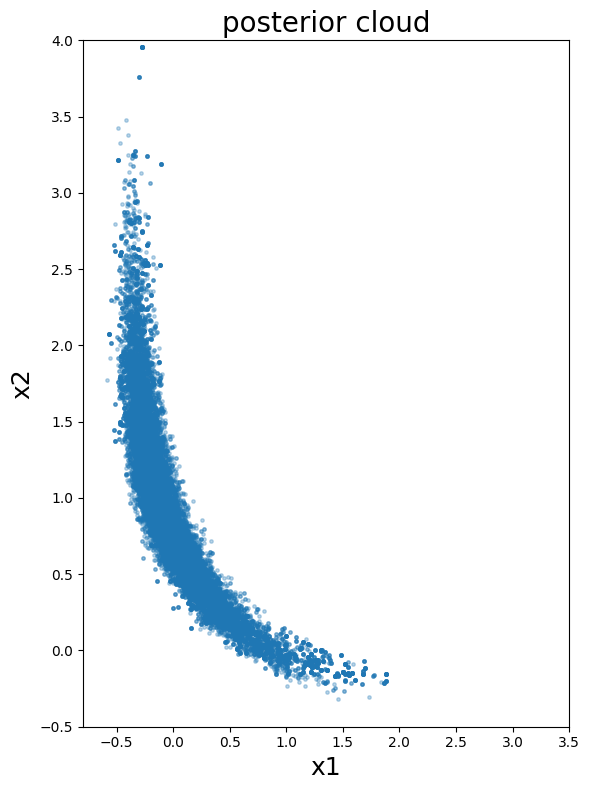

In [32]:
# posterior cloud
x1 = samples_mixed1[:, 0]
x2 = samples_mixed1[:, 1]
plt.figure(figsize=(6, 8))
plt.scatter(x1, x2, s = 6, alpha = 0.3)
plt.title("posterior cloud", fontsize = 20)
plt.xlabel("x1", fontsize = 18)
plt.ylabel("x2", fontsize = 18)
plt.ylim(-0.5, 4)
plt.xlim(-0.8, 3.5)
plt.tight_layout()
plt.show()

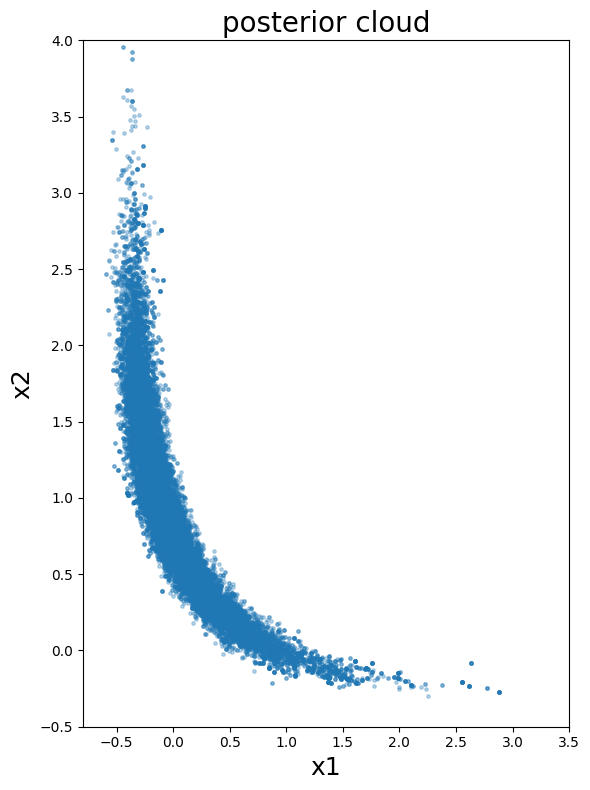

In [33]:
# posterior cloud
x1 = samples_mixed2[:, 0]
x2 = samples_mixed2[:, 1]
plt.figure(figsize=(6, 8))
plt.scatter(x1, x2, s = 6, alpha = 0.3)
plt.title("posterior cloud", fontsize = 20)
plt.xlabel("x1", fontsize = 18)
plt.ylabel("x2", fontsize = 18)
plt.ylim(-0.5, 4)
plt.xlim(-0.8, 3.5)
plt.tight_layout()
plt.show()

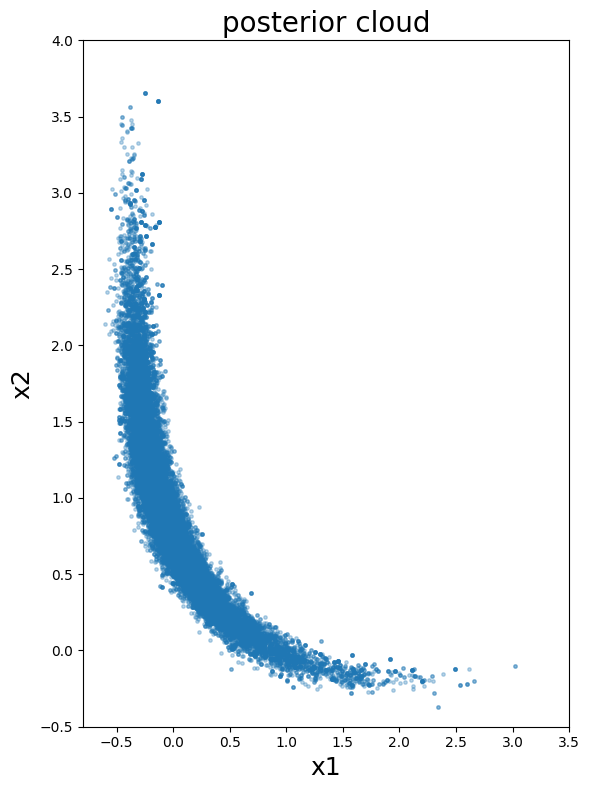

In [34]:
# posterior cloud
x1 = samples_mixed3[:, 0]
x2 = samples_mixed3[:, 1]
plt.figure(figsize=(6, 8))
plt.scatter(x1, x2, s = 6, alpha = 0.3)
plt.title("posterior cloud", fontsize = 20)
plt.xlabel("x1", fontsize = 18)
plt.ylabel("x2", fontsize = 18)
plt.ylim(-0.5, 4)
plt.xlim(-0.8, 3.5)
plt.tight_layout()
plt.show()

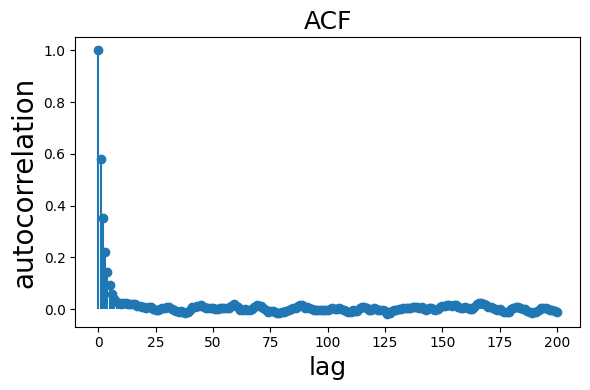

In [35]:
# acf 2D
max_lag = 200
acf = acf_2d(samples_mixed3, max_lag)

fig, ax = plt.subplots(figsize=(6, 4))
ax.stem(range(max_lag + 1), acf, basefmt=" ", markerfmt="o")
ax.set_title("ACF", fontsize = 18)
ax.set_xlabel("lag", fontsize = 18)
ax.set_ylabel("autocorrelation", fontsize = 20)

plt.tight_layout()
plt.show()

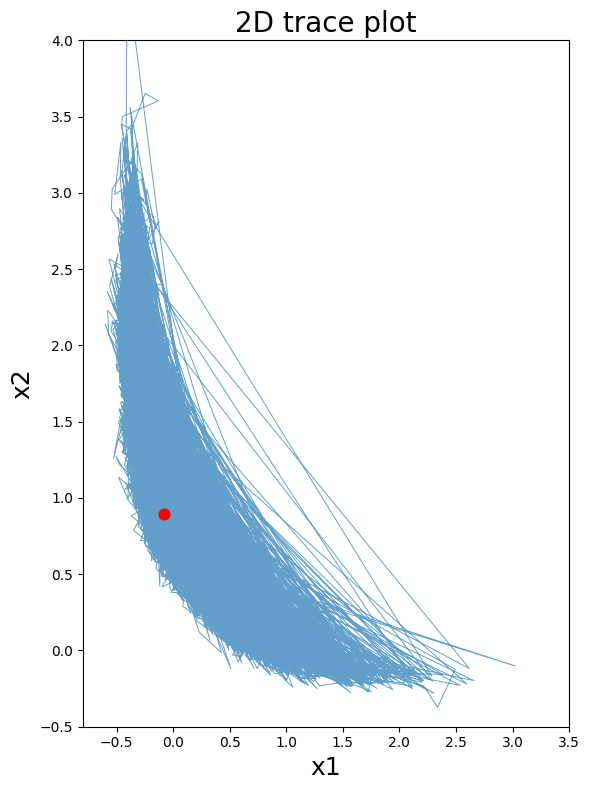

In [36]:
# 2d trace plot
plt.figure(figsize=(6, 8))

plt.plot(samples_mixed3[:, 0], samples_mixed3[:, 1], linewidth=0.7, alpha=0.7)

# starting point
plt.scatter(samples_mixed3[0, 0], samples_mixed3[0, 1], color="red", s=60, zorder=3)

plt.xlabel("x1", fontsize=18)
plt.ylabel("x2", fontsize=18)
plt.title("2D trace plot", fontsize=20)
plt.ylim(-0.5, 4)
plt.xlim(-0.8, 3.5)

plt.tight_layout()
plt.show()

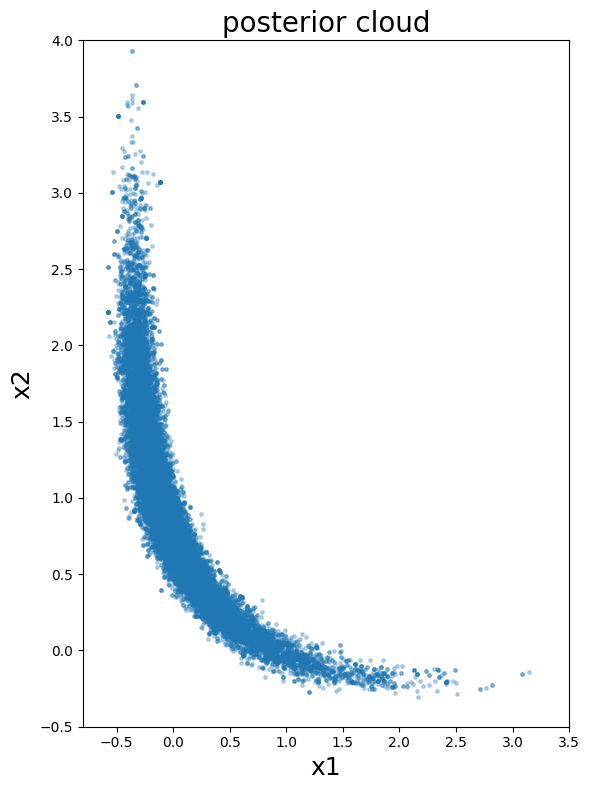

In [37]:
# posterior cloud
x1 = samples_mixed4[:, 0]
x2 = samples_mixed4[:, 1]
plt.figure(figsize=(6, 8))
plt.scatter(x1, x2, s = 6, alpha = 0.3)
plt.title("posterior cloud", fontsize = 20)
plt.xlabel("x1", fontsize = 18)
plt.ylabel("x2", fontsize = 18)
plt.ylim(-0.5, 4)
plt.xlim(-0.8, 3.5)
plt.tight_layout()
plt.show()

In [38]:
posterior_samples = np.load("posterior_samples.npy")
samples_training = posterior_samples[22000:]

In [109]:
S1 = mp.TriangularTransport2D(degree = 1)
thetaS1 = np.load("thetaS1.npy")

S2 = mp.TriangularTransport2D(degree = 2)
thetaS2 = np.load("thetaS2.npy")

S3 = mp.TriangularTransport2D(degree = 3)
thetaS3 = np.load("thetaS3.npy")

S4 = mp.TriangularTransport2D(degree = 4)
thetaS4 = np.load("thetaS4.npy")

In [ ]:
def mh_inverse(n_iter, S, thetaS, log_posterior, sigma = 0.2, seed = 12):
    """ inverse map-based metroplis hastings algorithm """

    rng = np.random.default_rng(seed)

    # starting point of the chain
    x = np.zeros(2, dtype = float).reshape((1, 2))
    chain = [x[0].copy()] * n_iter
    acc_count = 0

    # depushed starting point
    xhat = S.forward(x, thetaS)

    for i in range(n_iter):

        u = rng.uniform()

        # prior-space proposal
        yhat = xhat + sigma * rng.normal(size=(1, 2))

        y = np.array(S.inverse(yhat[0], thetaS), dtype=float).reshape(1, 2)

        # log-acceptance rate
        log_acc = (log_posterior(y)[0] - log_posterior(x)[0] - S.log_det_jacobian(y, thetaS)[0] + S.log_det_jacobian(x, thetaS)[0])

        if log_acc >= 0:
            acc = 1.0

        else:
            acc = np.exp(log_acc)

        if u < acc:
            x = y
            xhat = yhat
            acc_count += 1

        chain[i] = x[0].copy()

    return np.array(chain), acc_count / n_iter

In [151]:
n_iter = 25000
samples_inverse1, acc_inverse1 = mh_inverse(n_iter, S1, thetaS1, log_posterior, sigma = 0.2, seed = 12)


# posterior means
mean_x = np.array(samples_inverse1).mean(axis = 0)

# global ess
ess_global = ess_2d(samples_inverse1, max_lag = 2000)

print("acceptance rate:", round(acc_inverse1, 3))
print("e[x|y] is approximately equal to", mean_x)
print("effective sample size is approximately", int(ess_global), "over", len(samples_inverse1))

acceptance rate: 0.887
e[x|y] is approximately equal to [0.0866481  0.93810311]
effective sample size is approximately 84 over 25000


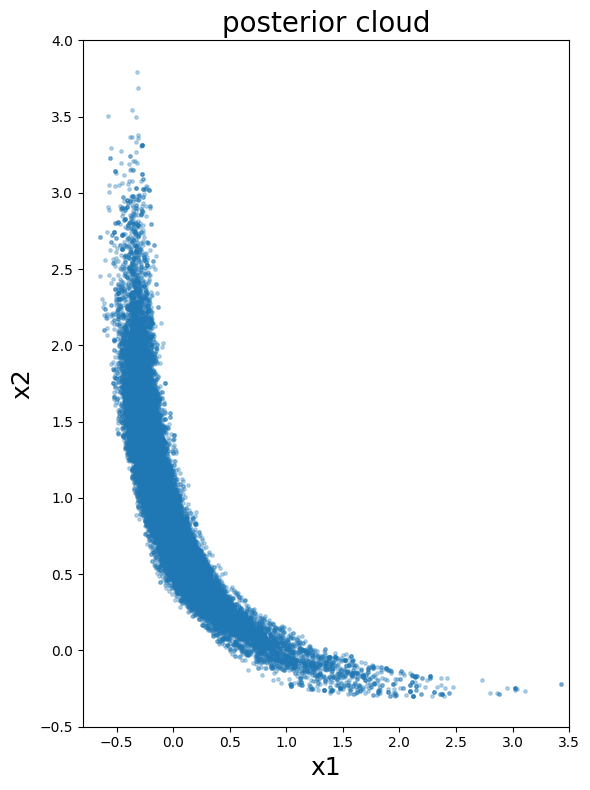

In [173]:
# posterior cloud
x1 = samples_inverse1[700:, 0]
x2 = samples_inverse1[700:, 1]
plt.figure(figsize=(6, 8))
plt.scatter(x1, x2, s = 6, alpha = 0.3)
plt.title("posterior cloud", fontsize = 20)
plt.xlabel("x1", fontsize = 18)
plt.ylabel("x2", fontsize = 18)
plt.ylim(-0.5, 4)
plt.xlim(-0.8, 3.5)
plt.tight_layout()
plt.show()

In [ ]:
n_iter = 25000
samples_inverse2, acc_inverse2 = mh_inverse(n_iter, S2, thetaS2, log_posterior, sigma = 0.2, seed = 120)


# posterior means
mean_x = np.array(samples_inverse2).mean(axis = 0)

# global ess
ess_global = ess_2d(samples_inverse2, max_lag = 2000)

print("acceptance rate:", round(acc_inverse2, 3))
print("e[x|y] is approximately equal to", mean_x)
print("effective sample size is approximately", int(ess_global), "over", len(samples_inverse2))

acceptance rate: 0.904
e[x|y] is approximately equal to [0.06472755 0.88375133]
effective sample size is approximately 234 over 25000


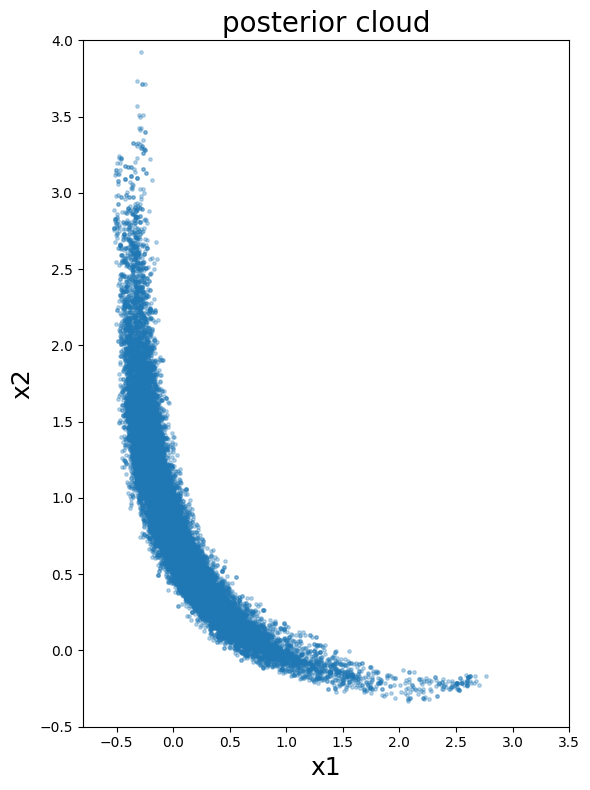

In [170]:
# posterior cloud
x1 = samples_inverse2[200:, 0]
x2 = samples_inverse2[200:, 1]
plt.figure(figsize=(6, 8))
plt.scatter(x1, x2, s = 6, alpha = 0.3)
plt.title("posterior cloud", fontsize = 20)
plt.xlabel("x1", fontsize = 18)
plt.ylabel("x2", fontsize = 18)
plt.ylim(-0.5, 4)
plt.xlim(-0.8, 3.5)
plt.tight_layout()
plt.show()

In [ ]:
n_iter = 25000
samples_inverse3, acc_inverse3 = mh_inverse(n_iter, S3, thetaS3, log_posterior, sigma = 0.2, seed = 12)


# posterior means
mean_x = np.array(samples_inverse3).mean(axis = 0)

# global ess
ess_global = ess_2d(samples_inverse3, max_lag = 2000)

print("acceptance rate:", round(acc_inverse3, 3))
print("e[x|y] is approximately equal to", mean_x)
print("effective sample size is approximately", int(ess_global), "over", len(samples_inverse3))

acceptance rate: 0.903
e[x|y] is approximately equal to [0.01050551 0.9761742 ]
effective sample size is approximately 203 over 25000


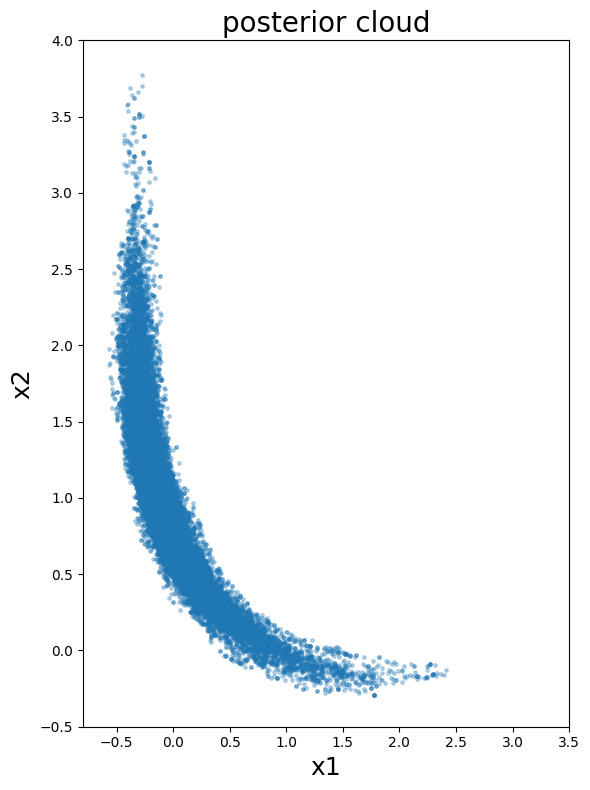

In [168]:
# posterior cloud
x1 = samples_inverse3[200:, 0]
x2 = samples_inverse3[200:, 1]
plt.figure(figsize=(6, 8))
plt.scatter(x1, x2, s = 6, alpha = 0.3)
plt.title("posterior cloud", fontsize = 20)
plt.xlabel("x1", fontsize = 18)
plt.ylabel("x2", fontsize = 18)
plt.ylim(-0.5, 4)
plt.xlim(-0.8, 3.5)
plt.tight_layout()
plt.show()

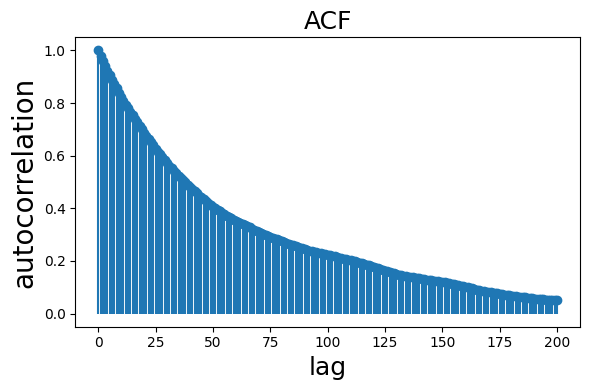

In [162]:
# acf 2D
max_lag = 200
acf = acf_2d(samples_inverse3, max_lag)

fig, ax = plt.subplots(figsize=(6, 4))
ax.stem(range(max_lag + 1), acf, basefmt=" ", markerfmt="o")
ax.set_title("ACF", fontsize = 18)
ax.set_xlabel("lag", fontsize = 18)
ax.set_ylabel("autocorrelation", fontsize = 20)

plt.tight_layout()
plt.show()

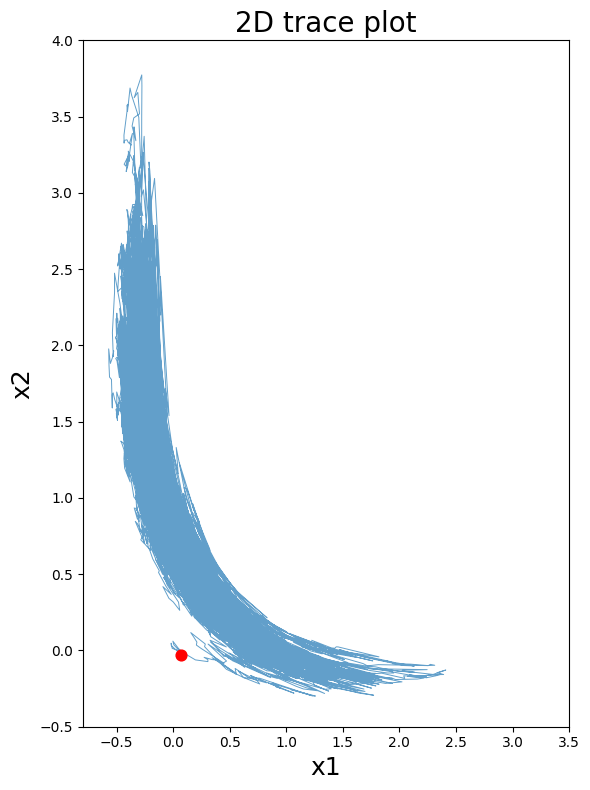

In [163]:
# 2d trace plot
plt.figure(figsize=(6, 8))

plt.plot(samples_inverse3[:, 0], samples_inverse3[:, 1], linewidth=0.7, alpha=0.7)

# starting point
plt.scatter(samples_inverse3[0, 0], samples_inverse3[0, 1], color="red", s=60, zorder=3)

plt.xlabel("x1", fontsize=18)
plt.ylabel("x2", fontsize=18)
plt.title("2D trace plot", fontsize=20)
plt.ylim(-0.5, 4)
plt.xlim(-0.8, 3.5)

plt.tight_layout()
plt.show()

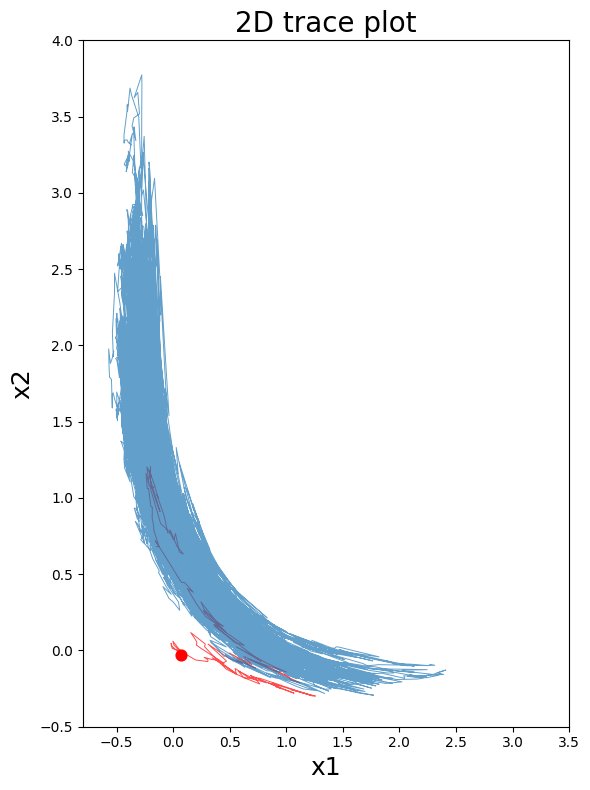

In [177]:
plt.figure(figsize=(6, 8))

plt.plot(
    samples_inverse3[:200, 0],
    samples_inverse3[:200, 1],
    color="red",
    linewidth=0.7,
    alpha=0.7
)

plt.plot(
    samples_inverse3[200:, 0],
    samples_inverse3[200:, 1],
    linewidth=0.7,
    alpha=0.7
)

plt.scatter(
    samples_inverse3[0, 0],
    samples_inverse3[0, 1],
    color="red",
    s=60,
    zorder=3
)

plt.xlabel("x1", fontsize=18)
plt.ylabel("x2", fontsize=18)
plt.title("2D trace plot", fontsize=20)
plt.ylim(-0.5, 4)
plt.xlim(-0.8, 3.5)

plt.tight_layout()
plt.show()


In [ ]:
n_iter = 25000
samples_inverse4, acc_inverse4 = mh_inverse(n_iter, S4, thetaS4, log_posterior, sigma = 0.2, seed = 120)


# posterior means
mean_x = np.array(samples_inverse4).mean(axis = 0)

# global ess
ess_global = ess_2d(samples_inverse4, max_lag = 2000)

print("acceptance rate:", round(acc_inverse4, 3))
print("e[x|y] is approximately equal to", mean_x)
print("effective sample size is approximately", int(ess_global), "over", len(samples_inverse4))

acceptance rate: 0.901
e[x|y] is approximately equal to [0.05887015 0.90722562]
effective sample size is approximately 216 over 25000


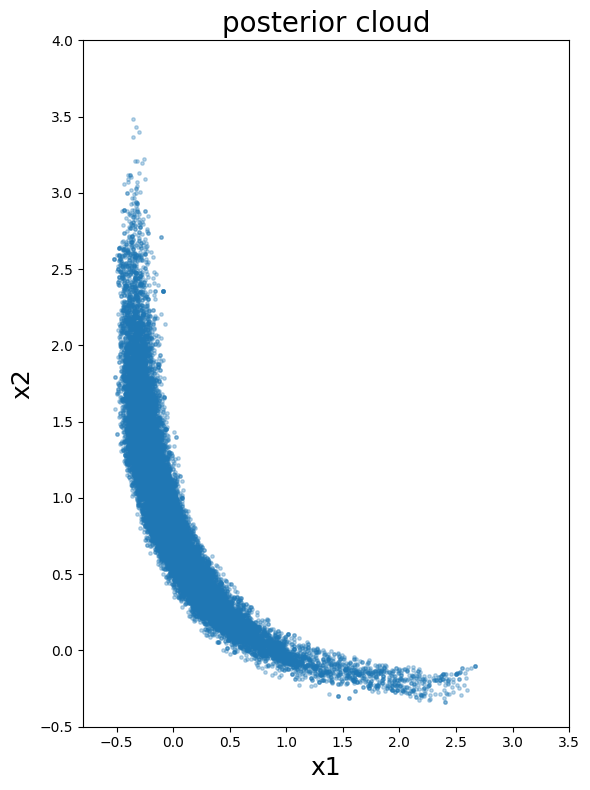

In [176]:
# posterior cloud
x1 = samples_inverse4[500:, 0]
x2 = samples_inverse4[500:, 1]
plt.figure(figsize=(6, 8))
plt.scatter(x1, x2, s = 6, alpha = 0.3)
plt.title("posterior cloud", fontsize = 20)
plt.xlabel("x1", fontsize = 18)
plt.ylabel("x2", fontsize = 18)
plt.ylim(-0.5, 4)
plt.xlim(-0.8, 3.5)
plt.tight_layout()
plt.show()

In [193]:
def mh_inverse_adaptive(n_iter, S, thetaS, log_posterior, log_prior, sigma=0.2, adapt_every=5000, maxiter=100, seed=12):
    """ adaptive mh with the inverse map instead of the original one """

    rng = np.random.default_rng(seed)

    x = np.zeros(2, dtype=float).reshape((1, 2))
    chain = np.empty((n_iter, 2), dtype=float)
    acc_count = 0

    xhat = S.forward(x, thetaS)

    for i in range(n_iter):

        if i > 0 and adapt_every > 0 and (i % adapt_every == 0):
            Z = chain[:i].copy()

            def neg_log_KL(theta):
                Y = S.forward(Z, theta)
                log_phi = log_prior(Y)
                log_det = S.log_det_jacobian(Z, theta)
                return np.mean(-log_phi - log_det)

            res = opt.minimize(neg_log_KL, thetaS, method="L-BFGS-B", options={"maxiter": maxiter})
            thetaS = res.x
            xhat = S.forward(x, thetaS)

        u = rng.uniform()
        yhat = xhat + sigma * rng.normal(size=(1, 2))
        y = np.array(S.inverse(yhat[0], thetaS), dtype=float).reshape(1, 2)

        log_acc = (log_posterior(y)[0] - log_posterior(x)[0]) - (S.log_det_jacobian(y, thetaS)[0] - S.log_det_jacobian(x, thetaS)[0])

        if log_acc >= 0:
            acc = 1.0

        else:
            acc = np.exp(log_acc)

        if u < acc:
            x = y
            xhat = yhat
            acc_count += 1

        chain[i] = x[0].copy()

    return chain, acc_count / n_iter, thetaS

In [194]:
finale_chain, acc_rate, thetaS = mh_inverse_adaptive(25000, S3, thetaS3, log_posterior, log_prior)

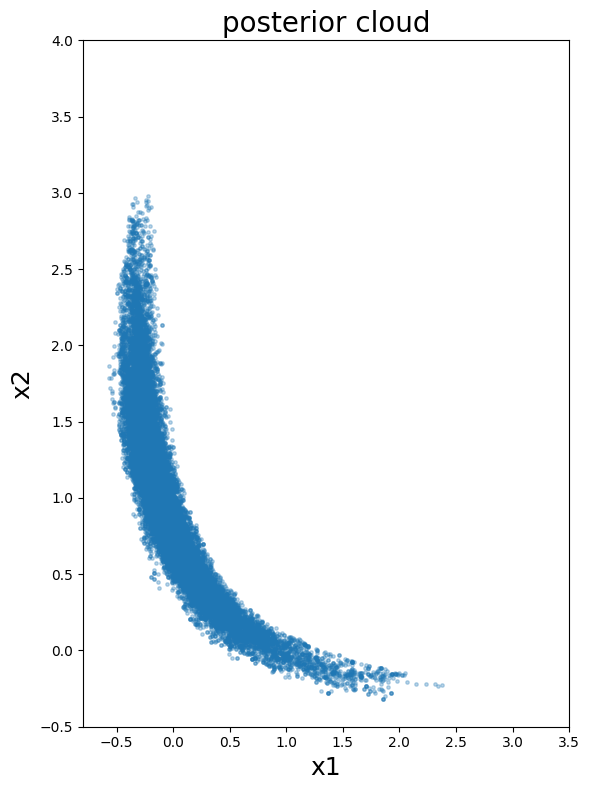

In [195]:
# posterior cloud
x1 = finale_chain[500:, 0]
x2 = finale_chain[500:, 1]
plt.figure(figsize=(6, 8))
plt.scatter(x1, x2, s = 6, alpha = 0.3)
plt.title("posterior cloud", fontsize = 20)
plt.xlabel("x1", fontsize = 18)
plt.ylabel("x2", fontsize = 18)
plt.ylim(-0.5, 4)
plt.xlim(-0.8, 3.5)
plt.tight_layout()
plt.show()

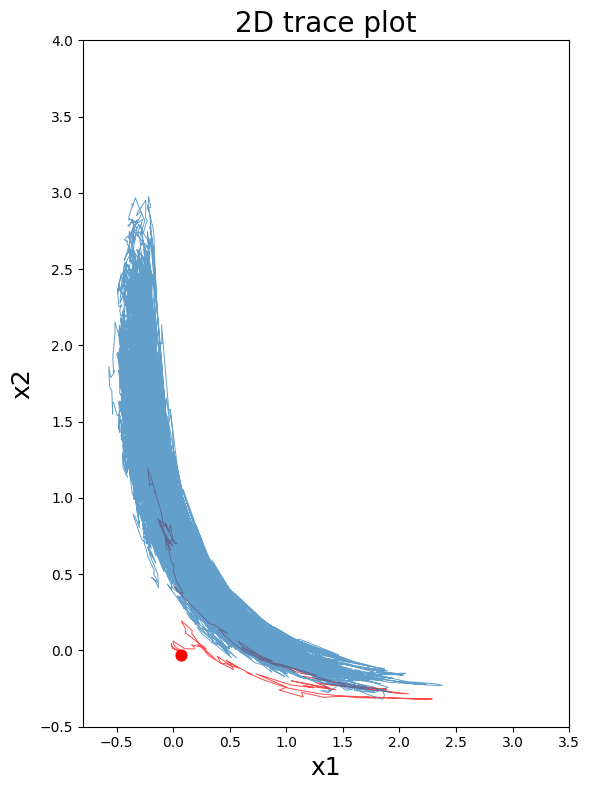

In [196]:
plt.figure(figsize=(6, 8))

plt.plot(
    finale_chain[:200, 0],
    finale_chain[:200, 1],
    color="red",
    linewidth=0.7,
    alpha=0.7
)

plt.plot(
    finale_chain[200:, 0],
    finale_chain[200:, 1],
    linewidth=0.7,
    alpha=0.7
)

plt.scatter(
    finale_chain[0, 0],
    finale_chain[0, 1],
    color="red",
    s=60,
    zorder=3
)

plt.xlabel("x1", fontsize=18)
plt.ylabel("x2", fontsize=18)
plt.title("2D trace plot", fontsize=20)
plt.ylim(-0.5, 4)
plt.xlim(-0.8, 3.5)

plt.tight_layout()
plt.show()


In [ ]:
# posterior means
mean_x = np.array(finale_chain).mean(axis = 0)

# global ess
ess_global = ess_2d(finale_chain, max_lag = 2000)

print("acceptance rate:", round(acc_rate, 3))
print("e[x|y] is approximately equal to", mean_x)
print("effective sample size is approximately", int(ess_global), "over", len(finale_chain))

: 